In [2]:
import os
print(os.getcwd())


/content


In [3]:
print(os.listdir())


['.config', 'sample_data']


In [7]:
from google.colab import files
uploaded = files.upload()


Saving daily_sunspots_time_series_1850-01_2025-01.csv to daily_sunspots_time_series_1850-01_2025-01.csv


Dataset Preview:
         date  year  month  day  date_frac  counts   std  nobs indicator
0  1850-01-01  1850      1    1   1850.001     253  19.6     1       NaN
1  1850-01-02  1850      1    2   1850.004     162  15.5     1       NaN
2  1850-01-03  1850      1    3   1850.007     217  18.1     1       NaN
3  1850-01-04  1850      1    4   1850.010      99  12.0     1       NaN
4  1850-01-05  1850      1    5   1850.012     108  12.6     1       NaN


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training LSTM Model...
Epoch 1/15
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - loss: 0.0067
Epoch 2/15
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - loss: 1.8010e-06
Epoch 3/15
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 1.2607e-06
Epoch 4/15
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 1.1423e-06
Epoch 5/15
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 3.1222e-06
Epoch 6/15
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 1.1624e-06
Epoch 7/15
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 1.4955e-06
Epoch 8/15
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 1.6226e-06
Epoch 9/15
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 1.6293e-06
Epoch 10/15
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9.9177e-07
Epoch 11/15
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 1.2011e-06
Epoch 12/15
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 1.5749e-06
Epoch 13/15
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - loss: 1.4256e-06
E

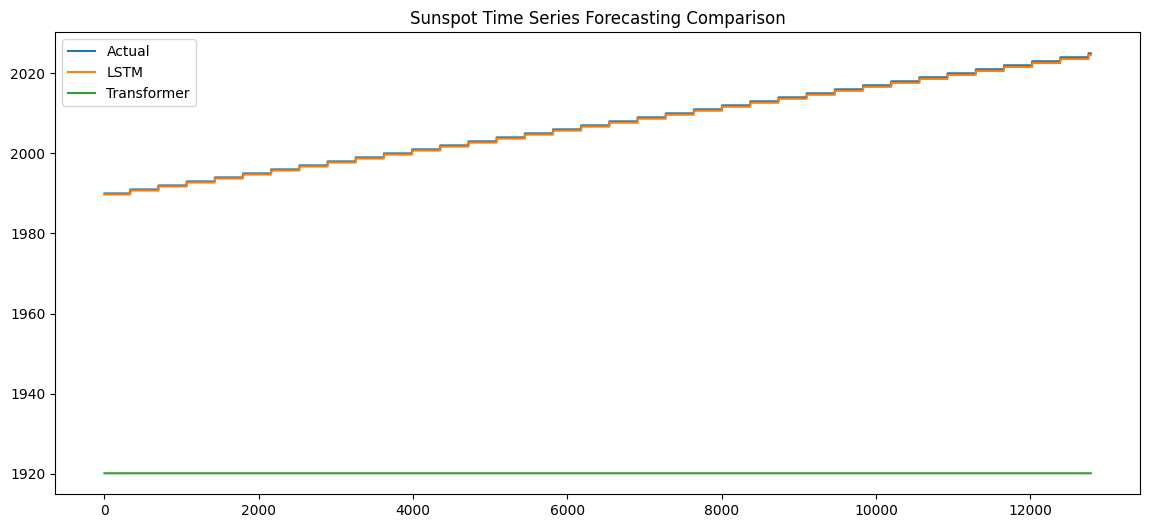

In [28]:

# Advanced Time Series Forecasting using LSTM & Transformer
# Dataset: Daily Sunspots (1850 - 2025)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Dropout


# 1. Load Dataset


file_path = "daily_sunspots_time_series_1850-01_2025-01.csv"
df = pd.read_csv(file_path)

print("Dataset Preview:")
print(df.head())

# Assuming column name contains sunspot values
# If column name is different, change below line
series = df.iloc[:, 1].values   # selecting 2nd column (sunspot values)


# 2. Preprocessing


scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series.reshape(-1, 1))

window_size = 30

def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X, y = create_sequences(series_scaled, window_size)

# Train-Test Split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


# 3. LSTM Baseline Model


lstm_model = Sequential([
    LSTM(64, input_shape=(window_size, 1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

print("\nTraining LSTM Model...")
lstm_model.fit(X_train, y_train, epochs=15, batch_size=32)


# 4. Transformer Model with Self-Attention


inputs = Input(shape=(window_size, 1))

attention = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
attention = Dropout(0.1)(attention)
attention = LayerNormalization()(attention + inputs)

dense = Dense(64, activation='relu')(attention)
outputs = Dense(1)(dense[:, -1, :])

transformer_model = Model(inputs, outputs)
transformer_model.compile(optimizer='adam', loss='mse')

print("\nTraining Transformer Model...")
transformer_model.fit(X_train, y_train, epochs=15, batch_size=32)


# 5. Evaluation


lstm_pred = lstm_model.predict(X_test)
transformer_pred = transformer_model.predict(X_test)

# Inverse scaling
y_test_actual = scaler.inverse_transform(y_test)
lstm_pred_actual = scaler.inverse_transform(lstm_pred)
transformer_pred_actual = scaler.inverse_transform(transformer_pred)

lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred_actual))
transformer_rmse = np.sqrt(mean_squared_error(y_test_actual, transformer_pred_actual))

print("\n==============================")
print("LSTM RMSE:", lstm_rmse)
print("Transformer RMSE:", transformer_rmse)
print("==============================")


# 6. Visualization


plt.figure(figsize=(14,6))
plt.plot(y_test_actual, label="Actual")
plt.plot(lstm_pred_actual, label="LSTM")
plt.plot(transformer_pred_actual, label="Transformer")
plt.legend()
plt.title("Sunspot Time Series Forecasting Comparison")
plt.show()
